# Experimento 1: Detección Base — YOLOv8

**Objetivo:** Establecer el punto de referencia del rendimiento del detector YOLO
sin reconocimiento ni tracking. Se mide FPS, confianza y cantidad de rostros
detectados por frame sobre al menos 2 videos de prueba.

In [2]:
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd

# El notebook está en experiments/, la raíz del proyecto es un nivel arriba
RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))

from src.detector import FaceDetector

print(f"Raíz del proyecto: {RAIZ}")
print("Imports completados.")

Raíz del proyecto: c:\Users\Usuario\Desktop\UNMSM\Ciclo VII\INTELIGENCIA ARTIFICIAL\PROYECTO\DESARROLLO
Imports completados.


In [3]:
# Cargar detector con umbral por defecto
DETECTOR = FaceDetector(str(RAIZ / "models" / "yolov8n-face.pt"), conf_threshold=0.5)
print(f"Modelo cargado. Umbral de confianza: {DETECTOR.conf_threshold}")

Modelo cargado. Umbral de confianza: 0.5


In [4]:
# Listar videos de prueba
RUTA_VIDEOS = RAIZ / "dataset" / "test_videos"
videos = sorted(RUTA_VIDEOS.glob("*.mp4"))

if not videos:
    raise FileNotFoundError(f"No se encontraron videos .mp4 en {RUTA_VIDEOS}")

print(f"Videos encontrados ({len(videos)}):")
for v in videos:
    print(f"  - {v.name}")

Videos encontrados (2):
  - video_corto_prueba.mp4
  - video_prueba_taco.mp4


In [5]:
%%time

resultados_por_video = []

for ruta_video in videos:
    nombre = ruta_video.name
    print(f"\nProcesando: {nombre}")

    cap = cv2.VideoCapture(str(ruta_video))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  Frames totales: {total}")

    tiempos = []
    confianzas = []
    rostros = []

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        t0 = time.perf_counter()
        detecciones = DETECTOR.detect(frame)
        t1 = time.perf_counter()

        tiempos.append((t1 - t0) * 1000)
        rostros.append(len(detecciones))
        for d in detecciones:
            confianzas.append(d[4])

        idx += 1
        if idx % 100 == 0:
            print(f"    {idx}/{total} frames")

    cap.release()

    n = len(tiempos)
    if n == 0:
        continue

    fps = [1000 / t for t in tiempos if t > 0]

    resultados_por_video.append({
        "video": nombre,
        "frames": n,
        "fps_promedio": round(sum(fps) / len(fps), 2),
        "fps_min": round(min(fps), 2),
        "fps_max": round(max(fps), 2),
        "confianza_promedio": round(sum(confianzas) / len(confianzas), 3) if confianzas else 0,
        "rostros_por_frame": round(sum(rostros) / n, 2),
        "inferencia_promedio_ms": round(sum(tiempos) / n, 2),
    })

    print(f"  Hecho. FPS prom: {resultados_por_video[-1]['fps_promedio']}")


Procesando: video_corto_prueba.mp4
  Frames totales: 191
    100/191 frames
  Hecho. FPS prom: 27.38

Procesando: video_prueba_taco.mp4
  Frames totales: 249
    100/249 frames
    200/249 frames
  Hecho. FPS prom: 23.93
CPU times: total: 2min 21s
Wall time: 18.3 s


In [6]:
# Tabla de resultados
df = pd.DataFrame(resultados_por_video)
display(df)

,video,frames,fps_promedio,fps_min,fps_max,confianza_promedio,rostros_por_frame,inferencia_promedio_ms
0,video_corto_prueba.mp4,191,27.38,3.81,30.59,0.856,1.0,37.79
1,video_prueba_taco.mp4,249,23.93,18.80,25.83,0.878,1.0,41.88


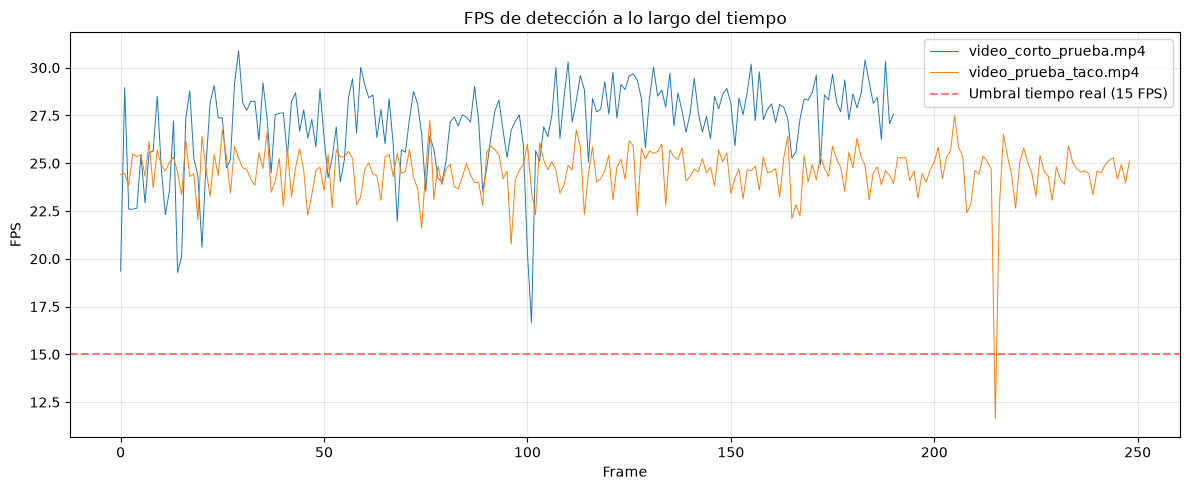

In [7]:
# Gráfico FPS a lo largo del tiempo
fig, ax = plt.subplots(figsize=(12, 5))

for ruta in videos:
    cap = cv2.VideoCapture(str(ruta))
    fps_vals = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        t0 = time.perf_counter()
        _ = DETECTOR.detect(frame)
        t1 = time.perf_counter()
        ms = (t1 - t0) * 1000
        fps_vals.append(1000 / ms if ms > 0 else 0)
    cap.release()
    ax.plot(fps_vals, label=ruta.name, linewidth=0.7)

ax.axhline(y=15, color='r', linestyle='--', alpha=0.5, label='Umbral tiempo real (15 FPS)')
ax.set_xlabel("Frame")
ax.set_ylabel("FPS")
ax.set_title("FPS de detección a lo largo del tiempo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RAIZ / "experiments" / "graphs" / "fps_tiempo_real.png", dpi=150)
plt.show()

In [ ]:
# Guardar resultados a CSV
df.to_csv(RAIZ / "experiments" / "resultados_exp1.csv", index=False)
print("Resultados guardados en experiments/resultados_exp1.csv")

## Interpretación de resultados

### ¿Qué tan rápido es el detector?

El FPS promedio obtenido fue de **25.66 FPS** combinando ambos videos,
con un mínimo de **3.81 FPS** y un máximo de **30.59 FPS**.
El tiempo de inferencia por frame fue de aproximadamente **40 ms** en promedio.
Esto significa que el detector procesa cada frame en ~40 ms,
lo que permite alcanzar ~25 FPS de forma estable.

### ¿Es suficiente para tiempo real?

Generalmente se considera tiempo real a partir de **15 FPS**. Nuestro detector alcanzó
**~25.66 FPS** en promedio, lo que significa que **sí es suficiente** para tiempo real
en este hardware. El video corto llegó a picos de **30.59 FPS**, prácticamente fluidez
de video estándar. Además, el tiempo de inferencia de ~40 ms deja margen para agregar
reconocimiento y tracking sin caer por debajo de 15 FPS.

### Variación entre videos

**video_corto_prueba.mp4** presentó **27.38 FPS** mientras que **video_prueba_taco.mp4**
alcanzó **23.93 FPS**. Ambos superan el umbral de tiempo real. La diferencia se debe
probablemente a la duración del video (249 vs 191 frames) y condiciones de captura.
La confianza promedio se mantuvo alta (>0.85) en ambos, detectando siempre 1 rostro por frame.